In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import pickle
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
#

In [2]:
from os.path import join, isdir
from os import listdir

def laplacian(u,xi2):
     ft_u = -np.fft.fftn(u,u.shape)*xi2
     #ft_u[0,0] = 0.0
     return np.fft.ifftn(ft_u,u.shape)


def get_mass_err(mypath):
     all_name_list = [f for f in listdir(mypath)]
     fold_all_list = [mypath+f for f in all_name_list] 
    
     fold_list = []
     dtname_list = []
     dt_list = []
     for i,dftn in enumerate(all_name_list):
          textract = dftn.split("_")[-1].split(".npz")[0]
          if textract=="initial":
               textract = "0.01"
          #print(textract)
          try:
               t_current = float(textract)
               fold_list.append(fold_all_list[i])
               dtname_list.append(textract)
               dt_list.append(t_current)

          except:
               print("Skipping ",textract)
               continue
      
     ind = np.argsort(dt_list)
     dtname_list = [dtname_list[i] for i in ind]
     # dt_list = [dt_list[i] for i in ind]
     fold_list = [fold_list[i] for i in ind]
     #print("Found folders: ",fold_list)

     frame = np.load(fold_list[0])['frame']
     mass_ini = np.mean(np.square(np.abs(frame)))
     mass_list = [mass_ini]
     for i,fold in enumerate(fold_list[1:]):
          #print("Folder ",i,": ",fold)
          data = np.load(fold)
          frame = data['frame']
          mass = np.mean(np.square(np.abs(frame)))
          mass_list.append(mass)
     mass_list.pop(1)  # remove initial mass from list to align with time steps
     dtname_list.pop(1) # remove initial time step
     mass_array = np.array(mass_list)
     mass_err = np.abs((mass_array - mass_ini)/mass_ini)


     t = [float(dt) for dt in dtname_list]
     return t,mass_err


In [3]:

fold_list = ["_data_sine_wave_E1_2048/imex_ARK4(3)6L[2]SA_2048_1e-07/","./_data_sine_wave_E1_2048/imex_ARK4(3)6L[2]SA_2048_5e-05/","./_data_sine_wave_multiRlx_E1/imex_ARK4(3)6L[2]SA_2048_5e-05/","./_data_sine_wave_projRlx_E1_2048/imex_ARK4(3)6L[2]SA_2048_5e-05/"]
folder_names = ["$\Delta t=1e-7$","$\Delta t=5e-5$","$\Delta t=5e-5,MR$","$\Delta t=5e-5,PR$"]
data_list = []
for folder in fold_list:
     with open(folder+"case_dict.pkl", 'rb') as file:
          data = pickle.load(file)
          data_list.append(data)
          print("Loaded ",folder)
          print("keys: ",data.keys())


FileNotFoundError: [Errno 2] No such file or directory: '_data_sine_wave_E1_2048/imex_ARK4(3)6L[2]SA_2048_1e-07/case_dict.pkl'

Plotting for  $\Delta t=1e-7$
Skipping  dict.pkl
Plotting for  $\Delta t=5e-5$
Skipping  dict.pkl
Plotting for  $\Delta t=5e-5,MR$
Skipping  dict.pkl
Plotting for  $\Delta t=5e-5,PR$
Skipping  Store
Skipping  dict.pkl


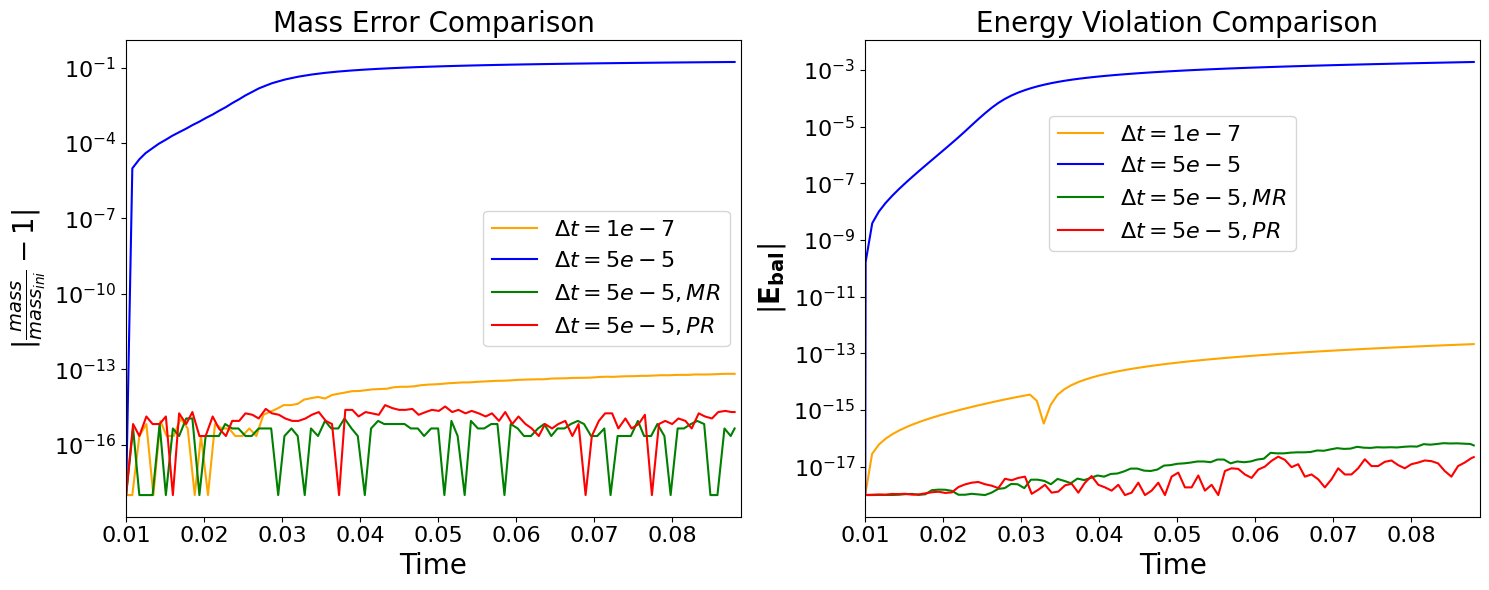

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

color_list = ["orange","blue", "green", "red"]


# Create a GridSpec with 2 rows and 2 columns
fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(1, 2, figure=fig)
x,y = data_list[0]['X']
# Mass Error Comparison (span the entire first row)
ax1 = fig.add_subplot(gs[0, 0])  
for data,names in zip(data_list[:],folder_names[:]):
    fold = fold_list[folder_names.index(names)]
    print("Plotting for ",names)
    ts,mass_err_l = get_mass_err(fold)
    # if names =="dt=5e-5,multiRlx":
    #     print("Mass error for multiRlx:")
    #     print(ts,mass_err_l )
    energy_violation = np.array(data['energy_err_l'])   
    if names !="large_dt":
        ax1.plot( ts,mass_err_l+1e-18, color=color_list[folder_names.index(names)], label=names)#'Mass Error')
        #ax1.plot(data['t_list'][:-1], energy_violation[:,1], label="Energy 2")#'Mass Error Relaxed')
        ax1.set_yscale('log')
        ax1.set_xlabel('Time',fontsize=20)
        ax1.set_ylabel(r"$|\frac{mass}{mass_{ini}}-1|$",fontsize=20)
        ax1.tick_params(axis='both', which='major', labelsize=16)
        ax1.legend(loc="best",fontsize=16)
ax1.set_title('Mass Error Comparison',fontsize=20)
ax1.set_xlim([0.01,0.0888])

    # Energy Violation Comparison (bottom-left subplot)
ax2 = fig.add_subplot(gs[0, 1])  
for data,names in zip(data_list,folder_names):
    #mass_err_l = data['mass_err_l']
    energy_violation = np.abs(np.array(data['energy_err_l']))   
    ts = data['t_list']
    ax2.plot(ts, energy_violation[:]+1e-18, color=color_list[folder_names.index(names)], label=names)#'Mass Error')
    #ax1.plot(data['t_list'][:-1], energy_violation[:,1], label="Energy 2")#'Mass Error Relaxed')
    ax2.set_yscale('log')
    ax2.set_xlabel('Time',fontsize=20)
    ax2.set_ylabel("$|\mathbf{E_{bal}}|$",fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(loc="center",bbox_to_anchor=(0.5, 0.7),fontsize=16)
ax2.set_title(' Energy Violation Comparison',fontsize=20)
ax2.set_xlim([0.01,0.0888])

plt.tight_layout()

plt.savefig("./figures_sine_wave_collapse/sine_collapse_mass_energy.pdf",dpi=300,bbox_inches='tight')



Max density is  4643.760920813051  at t =  0.088  for  $\Delta t=1e-7$ mass 1.0000001230660882
Max density is  704.4943367647624  at t =  0.088  for  $\Delta t=5e-5$ mass 0.8337075522864887
Max density is  2813.5548305609  at t =  0.0880  for  $\Delta t=5e-5,MR$ mass 1.000000123066155
Max density is  3829.710926875726  at t =  0.0880  for  $\Delta t=5e-5,PR$ mass 1.0000001230661566


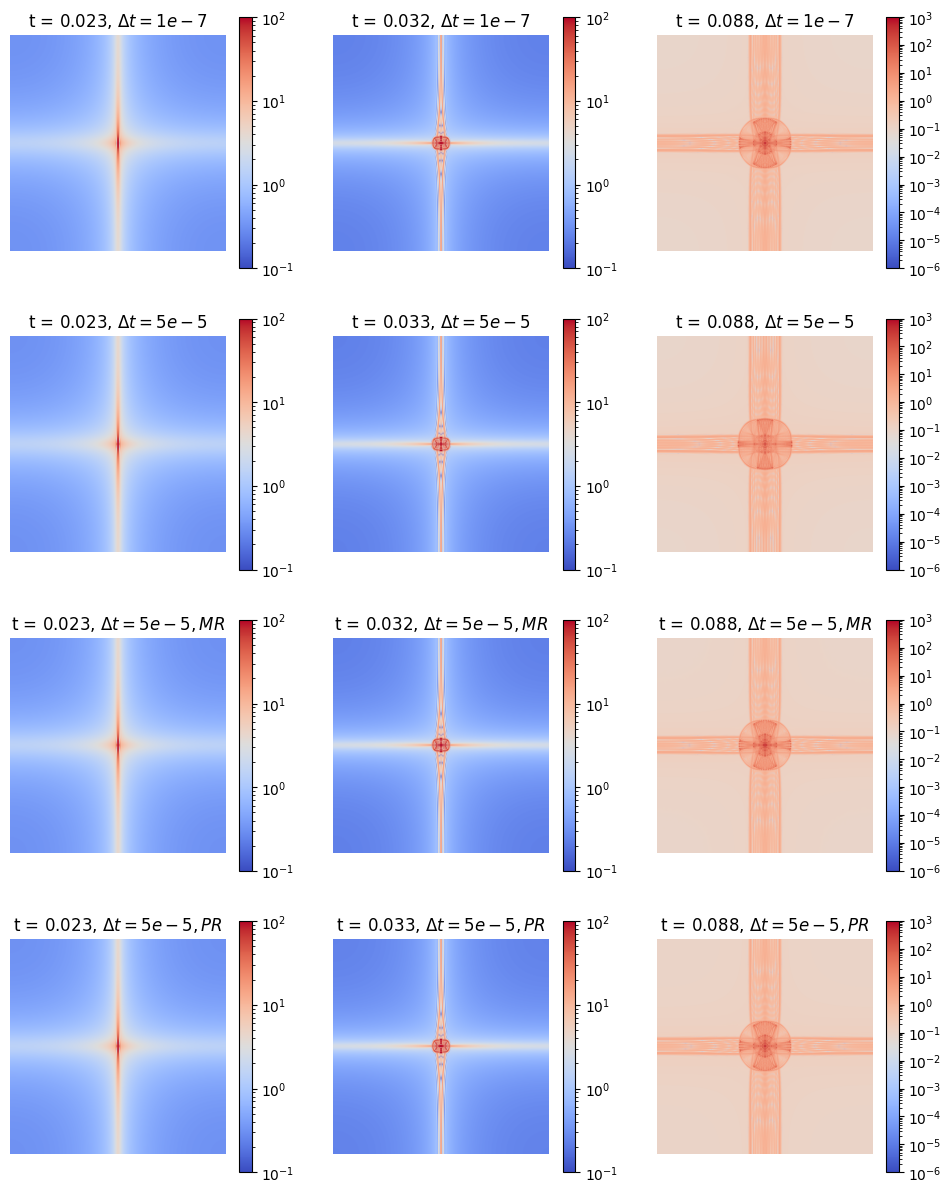

In [5]:
############ Relaxed vs Non-Relaxed ############
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cbook as cbook
import matplotlib.colors as colors



i_list = [["0.0232","0.0328","0.088"],["0.0236","0.0330","0.088"],["0.0236","0.0329","0.0880"],["0.0236","0.0330","0.0880"]]#list(range(0,len(data['t_list'])-1))






xlim = 0.5

cmap = plt.get_cmap('coolwarm')

fig = plt.figure(figsize=(4*len(i_list), 15))
gs = gridspec.GridSpec(4, len(i_list), figure=fig)
#plt.xlim([-xlim,xlim])
#plt.ylim([-xlim,xlim])
i2j=-1

cnt = 0
for il,fold in zip(i_list,fold_list):
    file_n = fold+"frame_"
    for icnt,i in enumerate(il):
        ax = fig.add_subplot(gs[cnt, icnt])
        frame = np.load(file_n + i + ".npz")['frame']
        Z = np.square(np.abs(frame))
        if icnt<2:
            pclm = ax.imshow(Z,norm=LogNorm(vmin=0.1, vmax=100.0),cmap=cmap)
        else:
            pclm = ax.imshow(Z,norm=LogNorm(vmin=1e-6, vmax=1e3),cmap=cmap)
        if icnt==2:
            print("Max density is ",np.max(Z)," at t = ",i," for ",folder_names[cnt],"mass",np.mean(Z))
        plt.colorbar(pclm, ax=ax)
  
        ax.set_title("t = "+i[:5]+", "+folder_names[cnt])#", mass = "+str(round(mass_massOnly,5)))
        ax.axis("off")
    cnt+=1


plt.savefig("./figures_sine_wave_collapse/sine_collapse_compare_relaxed_nonrelaxed_2048.pdf",dpi=300,bbox_inches='tight')










dt_list:  ['1e-07', '2e-07', '4e-07', '8e-07', '1.6e-06', '3.2e-06', '6.4e-06', '5e-05']
dt_list:  [1e-07, 2e-07, 4e-07, 8e-07, 1.6e-06, 3.2e-06, 6.4e-06, 5e-05]
dir_name_list:  ['./_data_sine_wave_E1_2048/imex_ARK4(3)6L[2]SA_2048_1e-07/', './_data_sine_wave_E1_2048/imex_ARK4(3)6L[2]SA_2048_2e-07/', './_data_sine_wave_E1_2048/imex_ARK4(3)6L[2]SA_2048_4e-07/', './_data_sine_wave_E1_2048/imex_ARK4(3)6L[2]SA_2048_8e-07/', './_data_sine_wave_E1_2048/imex_ARK4(3)6L[2]SA_2048_1.6e-06/', './_data_sine_wave_E1_2048/imex_ARK4(3)6L[2]SA_2048_3.2e-06/', './_data_sine_wave_E1_2048/imex_ARK4(3)6L[2]SA_2048_6.4e-06/', './_data_sine_wave_E1_2048/imex_ARK4(3)6L[2]SA_2048_5e-05/']
PR dt_list:  ['2e-06', '4e-06', '8e-06', '1.6e-05', '3.2e-05', '5e-05']
PR dt_list:  [2e-06, 4e-06, 8e-06, 1.6e-05, 3.2e-05, 5e-05]
PR dir_name_list:  ['./_data_sine_wave_projRlx_E1_2048/imex_ARK4(3)6L[2]SA_2048_2e-06/', './_data_sine_wave_projRlx_E1_2048/imex_ARK4(3)6L[2]SA_2048_4e-06/', './_data_sine_wave_projRlx_E1_2048/im

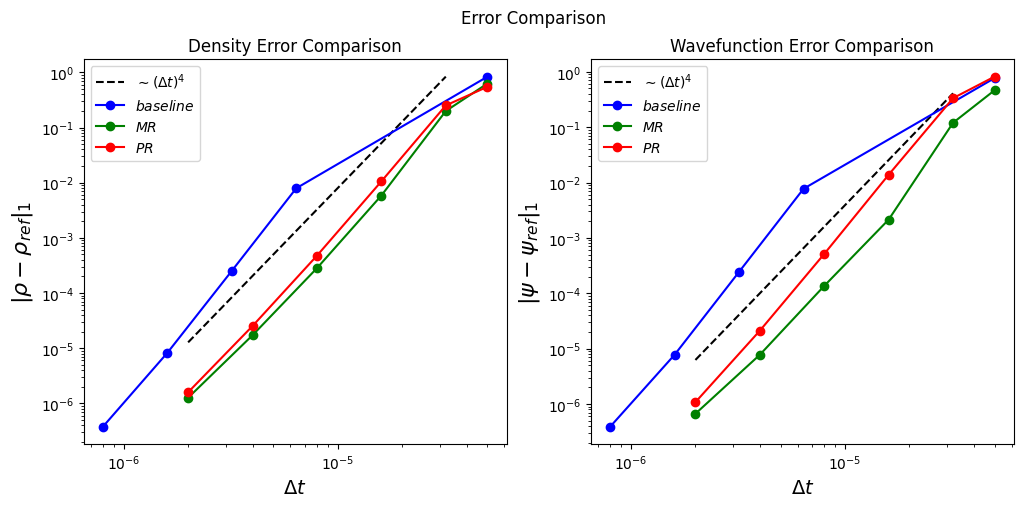

In [ ]:

from os.path import join, isdir
from os import listdir
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)
fig.suptitle("Error Comparison")


ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Density Error Comparison")
ax1.set_xlabel("$\Delta t$",fontsize=14)
ax1.set_ylabel(r"$|\rho-\rho_{ref}|_1$",fontsize=16)

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Wavefunction Error Comparison")
ax2.set_xlabel("$\Delta t$",fontsize=14)
ax2.set_ylabel(r"$|\psi-\psi_{ref}|_1$",fontsize=16)

ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xscale('log')
ax2.set_xscale('log')

mypath = "./_data_sine_wave_E1_2048/"
mypath_projrlax = "./_data_sine_wave_projRlx_E1_2048/"
mypath_multirlax = "./_data_sine_wave_multiRlx_E1_2048/"







err_density_max = []
err_density_mean = []
err_mean = []
dir_name_list = [f for f in listdir(mypath) if isdir(join(mypath, f))]
fold_list = [mypath+f+"/" for f in dir_name_list]
dtname_list = [ f.split('_')[-1] for f in dir_name_list ]
dt_list = [float(dt) for dt in dtname_list]
ind = np.argsort(dt_list)
dtname_list = [dtname_list[i] for i in ind]
dt_list = [dt_list[i] for i in ind]
fold_list = [fold_list[i] for i in ind]
last_t = ["0.088" for _ in range(len(fold_list)+1)]
print("dt_list: ",dtname_list)
print("dt_list: ",dt_list)
print("dir_name_list: ",fold_list)

err_density_max_PR = []
err_density_mean_PR = []
err_mean_PR = []
dir_name_list_PR = [f for f in listdir(mypath_projrlax) if isdir(join(mypath_projrlax, f))]
fold_list_PR = [mypath_projrlax+f+"/" for f in dir_name_list_PR]
dtname_list_PR = [ f.split('_')[-1] for f in dir_name_list_PR ]
dt_list_PR = [float(dt) for dt in dtname_list_PR]
ind = np.argsort(dt_list_PR)
dtname_list_PR = [dtname_list_PR[i] for i in ind]
dt_list_PR = [dt_list_PR[i] for i in ind]
fold_list_PR = [fold_list_PR[i] for i in ind]
last_t_PR = ["0.088000" for _ in range(len(fold_list_PR)+1)]

err_density_max_MR = []
err_density_mean_MR = []
err_mean_MR = []
dir_name_list_MR = [f for f in listdir(mypath_multirlax) if isdir(join(mypath_multirlax, f))]
fold_list_MR = [mypath_multirlax+f+"/" for f in dir_name_list_MR]
dtname_list_MR = [ f.split('_')[-1] for f in dir_name_list_MR ]
dt_list_MR = [float(dt) for dt in dtname_list_MR]
ind = np.argsort(dt_list_MR)
dtname_list_MR = [dtname_list_MR[i] for i in ind]
dt_list_MR = [dt_list_MR[i] for i in ind]
fold_list_MR = [fold_list_MR[i] for i in ind]
last_t_MR = ["0.088" for _ in range(len(fold_list_MR)+1)]





print("PR dt_list: ",dtname_list_PR)
print("PR dt_list: ",dt_list_PR)
print("PR dir_name_list: ",fold_list_PR)

ref = np.load(fold_list[0]+"frame_"+str(last_t[0])+".npz")['frame']
ref_density = np.square(np.abs(ref))
ref_mass = ref_density.mean()

wgt = ref_density/ref_density.sum()
for i,fold in enumerate(fold_list[3:]):
    
    frame = np.load(fold+"frame_"+last_t[i]+".npz")['frame']
    density = np.square(np.abs(frame))
    err_density_max.append(np.max(np.abs(density - ref_density)/ref_mass))
    err_density_mean.append( np.mean( np.abs(density - ref_density)/ref_mass) )
    err_mean.append( np.mean( np.abs(frame - ref) ) )
    print(fold,str(last_t[i]),err_density_mean[-1],err_mean[-1])
print(len(dt_list),len(err_density_max))
slp,intersect = np.polyfit(np.log2(dt_list[3:-2]), np.log2(err_density_max[:-2]), 1)
slp_sol,intersect_sol = np.polyfit(np.log2(dt_list[3:-1]), np.log2(err_mean[:-1]), 1)
print("Slope density err (max): ",slp)


for i,fold in enumerate(fold_list_MR[:]):
    
    frame = np.load(fold+"frame_"+last_t_MR[i]+".npz")['frame']
    density = np.square(np.abs(frame))
    err_density_max_MR.append(np.max(np.abs(density - ref_density)/ref_mass))
    err_density_mean_MR.append( np.mean( np.abs(density - ref_density)/ref_mass) )
    err_mean_MR.append( np.mean( np.abs(frame - ref) ) )
    print(fold,str(last_t_MR[i]),err_density_mean_MR[-1],err_mean_MR[-1])


slp,intersect = np.polyfit(np.log2(dt_list_MR[:-1]), np.log2(err_density_max_MR[:-1]), 1)
slp_sol,intersect_sol = np.polyfit(np.log2(dt_list_MR[:-1]), np.log2(err_mean_MR[:-1]), 1)




for i,fold in enumerate(fold_list_PR[:]):
    
    frame = np.load(fold+"frame_"+last_t_PR[i]+".npz")['frame']
    density = np.square(np.abs(frame))
    err_density_max_PR.append(np.max(np.abs(density - ref_density)/ref_mass))
    err_density_mean_PR.append( np.mean( np.abs(density - ref_density)/ref_mass) )
    err_mean_PR.append( np.mean( np.abs(frame - ref) ) )
    print(fold,str(last_t_PR[i]),err_density_mean_PR[-1],err_mean_PR[-1])

slp,intersect = np.polyfit(np.log2(dt_list_PR[:-1]), np.log2(err_density_max_PR[:-1]), 1)

slp_sol,intersect_sol = np.polyfit(np.log2(dt_list_PR[:-1]), np.log2(err_mean_PR[:-1]), 1)



ax1.plot((dt_list_PR[:-1]), 0.0003*np.power(2,intersect)*(np.array(dt_list_PR[:-1])**4.0), 'k--', label=r"$\sim(\Delta t)^{4}$")

ax2.plot((dt_list_PR[:-1]), .003*np.power(2,intersect_sol)*(np.array(dt_list_PR[:-1])**4.0), 'k--', label=r"$\sim(\Delta t)^{4}$")


print(len(err_density_max),len(err_density_mean))

ax1.plot((dt_list[3:]),err_density_mean[:],"o-",color="blue",label=r"$baseline$")
ax1.plot((dt_list_MR[:]),err_density_mean_MR[:],"o-",color="green",label=r"$MR$")
ax1.plot((dt_list_PR[:]),err_density_mean_PR[:],"o-",color="red",label=r"$PR$")

ax2.plot((dt_list[3:]),err_mean[:],"o-",color="blue",label=r"$baseline$")
ax2.plot((dt_list_MR[:]),err_mean_MR[:],"o-",color="green",label=r"$MR$")
ax2.plot((dt_list_PR[:]),err_mean_PR[:],"o-",color="red",label=r"$PR$")


ax1.legend()
ax2.legend()

plt.savefig("./_figures_sine_wave_collapse/sine_collapse_error_comparison_2048.pdf",dpi=300,bbox_inches='tight')


dt_list:  ['2e-06', '4e-06', '8e-06', '1.6e-05', '3.2e-05', '5e-05']
dt_list:  [2e-06, 4e-06, 8e-06, 1.6e-05, 3.2e-05, 5e-05]
dir_name_list:  6
./_data_sine_wave_multiRlx_E1_2048/imex_ARK4(3)6L[2]SA_2048_2e-06/
Energy violation max:  3.816865985599438e-16
./_data_sine_wave_multiRlx_E1_2048/imex_ARK4(3)6L[2]SA_2048_4e-06/ 0.088 1.606563509874114e-05 7.234929961108784e-06
Energy violation max:  3.4539428608870715e-15
./_data_sine_wave_multiRlx_E1_2048/imex_ARK4(3)6L[2]SA_2048_8e-06/ 0.088 0.0002818807947277534 0.00013540790149148448
Energy violation max:  1.0915205371497816e-16
./_data_sine_wave_multiRlx_E1_2048/imex_ARK4(3)6L[2]SA_2048_1.6e-05/ 0.088 0.0058617694676829655 0.002141580273412585
Energy violation max:  1.734723475976807e-17
./_data_sine_wave_multiRlx_E1_2048/imex_ARK4(3)6L[2]SA_2048_3.2e-05/ 0.088 0.19923717557071027 0.12023657694639421
Energy violation max:  7.589415207398531e-19
./_data_sine_wave_multiRlx_E1_2048/imex_ARK4(3)6L[2]SA_2048_5e-05/ 0.088 0.6251089778531993 0.

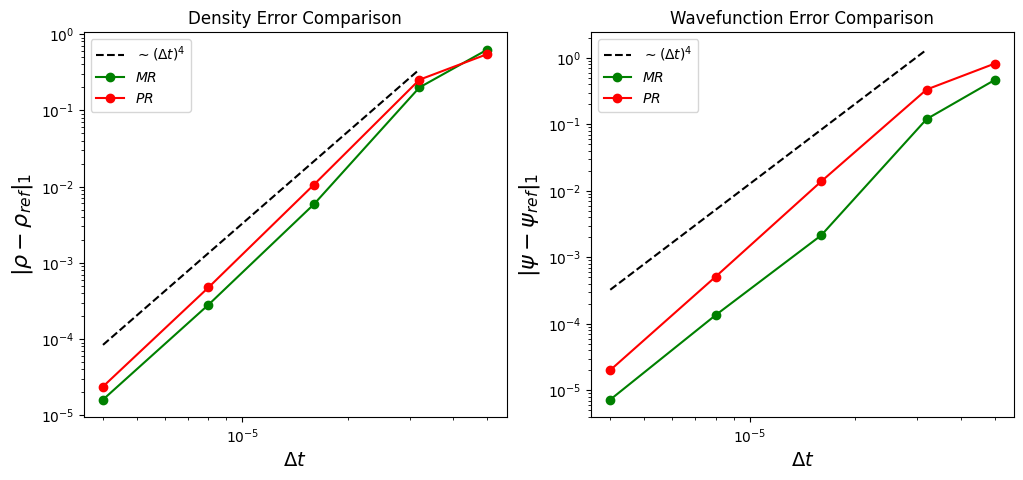

In [ ]:
from os.path import join, isdir
from os import listdir
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)
#fig.suptitle("Error Comparison (ref: most refined dt=2e-06)")

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Density Error Comparison")
ax1.set_xlabel("$\Delta t$",fontsize=14)
ax1.set_ylabel(r"$|\rho-\rho_{ref}|_1$",fontsize=16)

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Wavefunction Error Comparison")
ax2.set_xlabel("$\Delta t$",fontsize=14)
ax2.set_ylabel(r"$|\psi-\psi_{ref}|_1$",fontsize=16)



ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xscale('log')
ax2.set_xscale('log')


mypath = "./_data_sine_wave_multiRlx_E1_2048/"

err_density_max = []
err_density_mean = []
err_mean = []

dir_name_list = [f for f in listdir(mypath) if isdir(join(mypath, f))]
fold_list = [mypath+f+"/" for f in dir_name_list]
dtname_list = [ f.split('_')[-1] for f in dir_name_list ]
dt_list = [float(dt) for dt in dtname_list]
ind = np.argsort(dt_list)
dtname_list = [dtname_list[i] for i in ind]
dt_list = [dt_list[i] for i in ind]
fold_list = [fold_list[i] for i in ind]
last_t = ["0.088" for _ in range(len(fold_list)+1)]
print("dt_list: ",dtname_list)
print("dt_list: ",dt_list)
print("dir_name_list: ",len(fold_list))

print(fold_list[0])
ref = np.load(fold_list[0]+"frame_"+str(last_t[0])+".npz")['frame']
ref_density = np.square(np.abs(ref))



for i,fold in enumerate(fold_list[1:]):
    frame = np.load(fold+"frame_"+last_t[i+1]+".npz")['frame']
    dict_case = pickle.load( open( fold + "case_dict.pkl", "rb" ) )
    energy_violation = np.array(dict_case['energy_err_l'])
    
    density = np.square(np.abs(frame))
    err_density_max.append(np.max(np.abs(density - ref_density)))
    err_density_mean.append( np.mean( np.abs(density - ref_density) ) )
    err_mean.append( np.mean( np.abs(frame - ref) ) )
  

slp,intersect = np.polyfit(np.log2(dt_list[1:]), np.log2(err_mean), 1)
slp_density,intersect_density = np.polyfit(np.log2(dt_list[1:]), np.log2(err_density_mean), 1)







#plt.xscale('log')

ax1.plot((dt_list[1:-1]), 0.1*np.power(2,intersect_density)*(np.array(dt_list[1:-1])**4.0),  'k--', label=r"$\sim(\Delta t)^{4}$")
ax2.plot((dt_list[1:-1]), 0.1*np.power(2,intersect)*(np.array(dt_list[1:-1])**4.0),  'k--', label=r"$\sim(\Delta t)^{4}$")

print(len(err_density_max),len(err_density_mean))
#plt.plot(dt_list[1:],err_density_max[0::],"*-",label=r"$L_{\infty}$")
ax1.plot((dt_list[1:]),err_density_mean,"o-",color='g',label=r"$MR$")
ax2.plot((dt_list[1:]),err_mean,"o-",color='g',label=r"$MR$")





mypath = "./_data_sine_wave_projRlx_E1_2048/"

err_density_max = []
err_density_mean = []
err_mean = []

dir_name_list = [f for f in listdir(mypath) if isdir(join(mypath, f))]
fold_list = [mypath+f+"/" for f in dir_name_list]
dtname_list = [ f.split('_')[-1] for f in dir_name_list ]
dt_list = [float(dt) for dt in dtname_list]
ind = np.argsort(dt_list)
dtname_list = [dtname_list[i] for i in ind]
dt_list = [dt_list[i] for i in ind]
fold_list = [fold_list[i] for i in ind]
last_t = ["0.088000" for _ in range(len(fold_list)+1)]
print("dt_list: ",dtname_list)
print("dt_list: ",dt_list)
print("dir_name_list: ",len(fold_list))

print(fold_list[0])
ref = np.load(fold_list[0]+"frame_"+str(last_t[0])+".npz")['frame']

ref_density = np.square(np.abs(ref))


for i,fold in enumerate(fold_list[1:]):
    frame = np.load(fold+"frame_"+last_t[i+1]+".npz")['frame']
    dict_case = pickle.load( open( fold + "case_dict.pkl", "rb" ) )
    energy_violation = np.array(dict_case['energy_err_l'])
   
    density = np.square(np.abs(frame))
    err_density_max.append(np.max(np.abs(density - ref_density)))
    err_density_mean.append( np.mean( np.abs(density - ref_density) ) )
    err_mean.append( np.mean( np.abs(frame - ref) ) )


slp,intersect = np.polyfit(np.log2(dt_list[1:]), np.log2(err_mean), 1)
slp_density,intersect_density = np.polyfit(np.log2(dt_list[1:]), np.log2(err_density_mean), 1)

print("Slope density err (mean): ",slp_density)
print("Slope err (mean): ",slp)


#ax1.plot(np.log2(dt_list[1:]), 1*np.power(2,intersect_density)*(np.array(dt_list[1:])**slp_density), 'r--', label=f"Slope: {slp_density:.2f}")
#ax2.plot(np.log2(dt_list[1:]), 1*np.power(2,intersect)*(np.array(dt_list[1:])**slp), 'r--', label=f"Slope: {slp:.2f}")




#plt.xscale('log')

print(len(err_density_max),len(err_density_mean))
#plt.plot(dt_list[1:],err_density_max[0::],"*-",label=r"$L_{\infty}$")
ax1.plot((dt_list[1:]),err_density_mean,"o-",color='r',label=r"$PR$")
ax2.plot((dt_list[1:]),err_mean,"o-",color='r',label=r"$PR$")

ax1.legend()
ax2.legend()
# plt.legend()
# print(folder_names[1::],err_density_max[0::])
# print(np.array(err_density_max)/err_density_max[0])
# print(np.array(err_density_mean)/err_density_mean[0])
plt.savefig("./_figures_sine_wave_collapse/sin_wave_order_selfconvergence_2048.pdf")